# Analiza podatkov o prometnih nesrečah v Sloveniji

1. Datoteke moramo najprej združiti v en dataframe objekt in nato počistiti napačne in manjkajoče vrednosti

In [4]:
import pandas as pd
import glob
import os
import numpy as np

path = "PN_datasets"
files = glob.glob(os.path.join(path, "*.csv")) #Get all .csv files from the PN_datasets folder

df_list = []

# For every file(year) add a column in each file that will be the unique accident ID across all files format:
# <year>_<accident_id> 
                  
for file in files:
    temp_df = pd.read_csv(file, sep=';', encoding="windows-1250") # ALL FILES USE THE WINDOWS-1250 ENCODING
    year = "".join(filter(str.isdigit, os.path.basename(file)))
    temp_df['ID'] = year + "_" + temp_df['ZaporednaStevilkaPN'].astype(str)
    
    df_list.append(temp_df)    
                  
master_df = pd.concat(df_list, ignore_index=True) #merge all files into one dataframe          

#print(master_df.isnull().sum()) # Check the sum of missing value across all atributes


2. Znebiti se moramo manjkajočih vrednosti. Največkrat tako, da dodamo nov razred "NEZNANO" ali podobno. Pri starosti lahko tudi vnesemo mediano vseh starosti ampak to je lahko za nadalnjo analizo moteče

In [5]:
# Cleaning / inserting missing values

# Looking at the data it would seem that people without a UE entry were mostly foreigners by nationality.
# Add a new classification for "TUJINA" in such cases
master_df["UEStalnegaPrebivalisca"] = master_df["UEStalnegaPrebivalisca"].fillna("TUJINA")  
master_df["UEStalnegaPrebivalisca"] = master_df["UEStalnegaPrebivalisca"].replace("NEZNANA OBČ", "TUJINA")

# There is a few missing entries for UEStoritve. Added new class "NEZNANO" since it's not that crucial for our analysis
master_df["UpravnaEnotaStoritve"] = master_df["UpravnaEnotaStoritve"].fillna("NEZNANO")


In [6]:
# When looking at the sum of missing values by attribute it would seem that attributes 
# "Povzrocitelj", "PoskodbaUdelezenca", "VrstaUdelezenca", "Starost" and "UporabaVarnostnegaPasu" are all missing 
# 4300 times so there is obviously something wrong with these entries since no data about the person was gathered
# here we deleted all such entires
master_df.dropna(subset=["Povzrocitelj", "PoskodbaUdelezenca", "VrstaUdelezenca", "UporabaVarnostnegaPasu"], inplace=True)
    
#There was a lot of ages marked as -1 so I decided to input the median age instead (in case we use random algorithms
#that dont do well with missing values)
master_df["Starost"] = master_df["Starost"].replace("NEZNANA OBČ", np.nan) # set missing values to nan before calculating median


#####
# SET MISSING AGE TO MEDIAN??? BEWARE WHEN DOING ANALYSIS
#####

#master_df["Starost"] = master_df["Starost"].fillna(master_df["Starost"].median())


In [7]:
# For people entries wihout a nationality default to "Slovenija" if they aren't labled at "TUJINA" in "UEStalnegaPrebivalisca"
condition = (master_df["Drzavljanstvo"].isna()) & (master_df["UEStalnegaPrebivalisca"] != "TUJINA")
master_df.loc[condition, "Drzavljanstvo"] = "Slovenija"

master_df["Drzavljanstvo"] = master_df["Drzavljanstvo"].fillna("NEZNANO")

# Clean inconsistent missing nationality lables
master_df["Drzavljanstvo"] = master_df["Drzavljanstvo"].replace(["OSEBA IMA NEZNANO DRŽAVLJANSTVO", "BREZ DRŽAVLJANSTVA"], "NEZNANO")

# Lowercase Slovenija -> SLOVENIJA
master_df["Drzavljanstvo"] = master_df["Drzavljanstvo"].replace("Slovenija", "SLOVENIJA")

In [8]:
# Merge "TEKOČ (NORMALEN)" with "NORMALEN" for attribute "StanjePrometa"
master_df["StanjePrometa"] = master_df["StanjePrometa"].replace("NORMALEN", "TEKOČ (NORMALEN)")


# Cap driving licence years to 85 (max was around 90 which is probably wrong??)
master_df['VozniskiStazVLetih'] = master_df['VozniskiStazVLetih'].clip(upper=85)

# The value 0 in VozniskiStazVLetih could be interpreted as an underage person, a passenger, person driving without
# a valid licence, person walking ... It's not clear what the 0 is so I will not input or change it.
# The same goes for "VozniskiStazVMesecih"


# Cap sobriety test results at around 3.00 mg/l (considered to be a deadly dose)
# NOTE: Test result might be 0 even if it wasn't done
# First convert result strings to float
master_df['VrednostAlkotesta'] = master_df['VrednostAlkotesta'].astype(str).str.replace(',', '.')
master_df['VrednostAlkotesta'] = pd.to_numeric(master_df['VrednostAlkotesta'], errors='coerce')
master_df['VrednostAlkotesta'] = master_df['VrednostAlkotesta'].clip(upper=3.50)

#Medical sobriety test results look very wrong and inconsistent. I don't expect to use them in this analysis so
#I will simply delete the column
master_df = master_df.drop(columns=['VrednostStrokovnegaPregleda'])

master_df["PoskodbaUdelezenca"] = master_df["PoskodbaUdelezenca"].replace("BREZ POŠKODBE-UZ", "BREZ POŠKODBE")
master_df = master_df[master_df['PoskodbaUdelezenca'] != 'ODSTOP OD OGLEDA PN']

In [52]:
with pd.option_context('display.max_rows', None):
    print(master_df["VzrokNesrece"].value_counts(dropna=False))


VzrokNesrece
PREMIKI Z VOZILOM                   86108
NEUPOŠTEVANJE PRAVIL O PREDNOSTI    58659
NEPRILAGOJENA HITROST               56797
NEPRAVILNA STRAN / SMER VOŽNJE      50771
NEUSTREZNA VARNOSTNA RAZDALJA       48985
OSTALO                              39873
NEPRAVILNO PREHITEVANJE              9594
NEPRAVILNOSTI PEŠCA                  2280
NEPRAVILNOSTI NA TOVORU              1911
NEPRAVILNOSTI NA CESTI                822
NEPRAVILNOSTI NA VOZILU               821
Name: count, dtype: int64


In [10]:
master_df.to_csv("merged_clean.csv")

# Analiza
### 1. Kateri dnevi v letu so najnevarnejši?
Podatke združimo samo po dnevih, brez leta, in jih prestejemo.

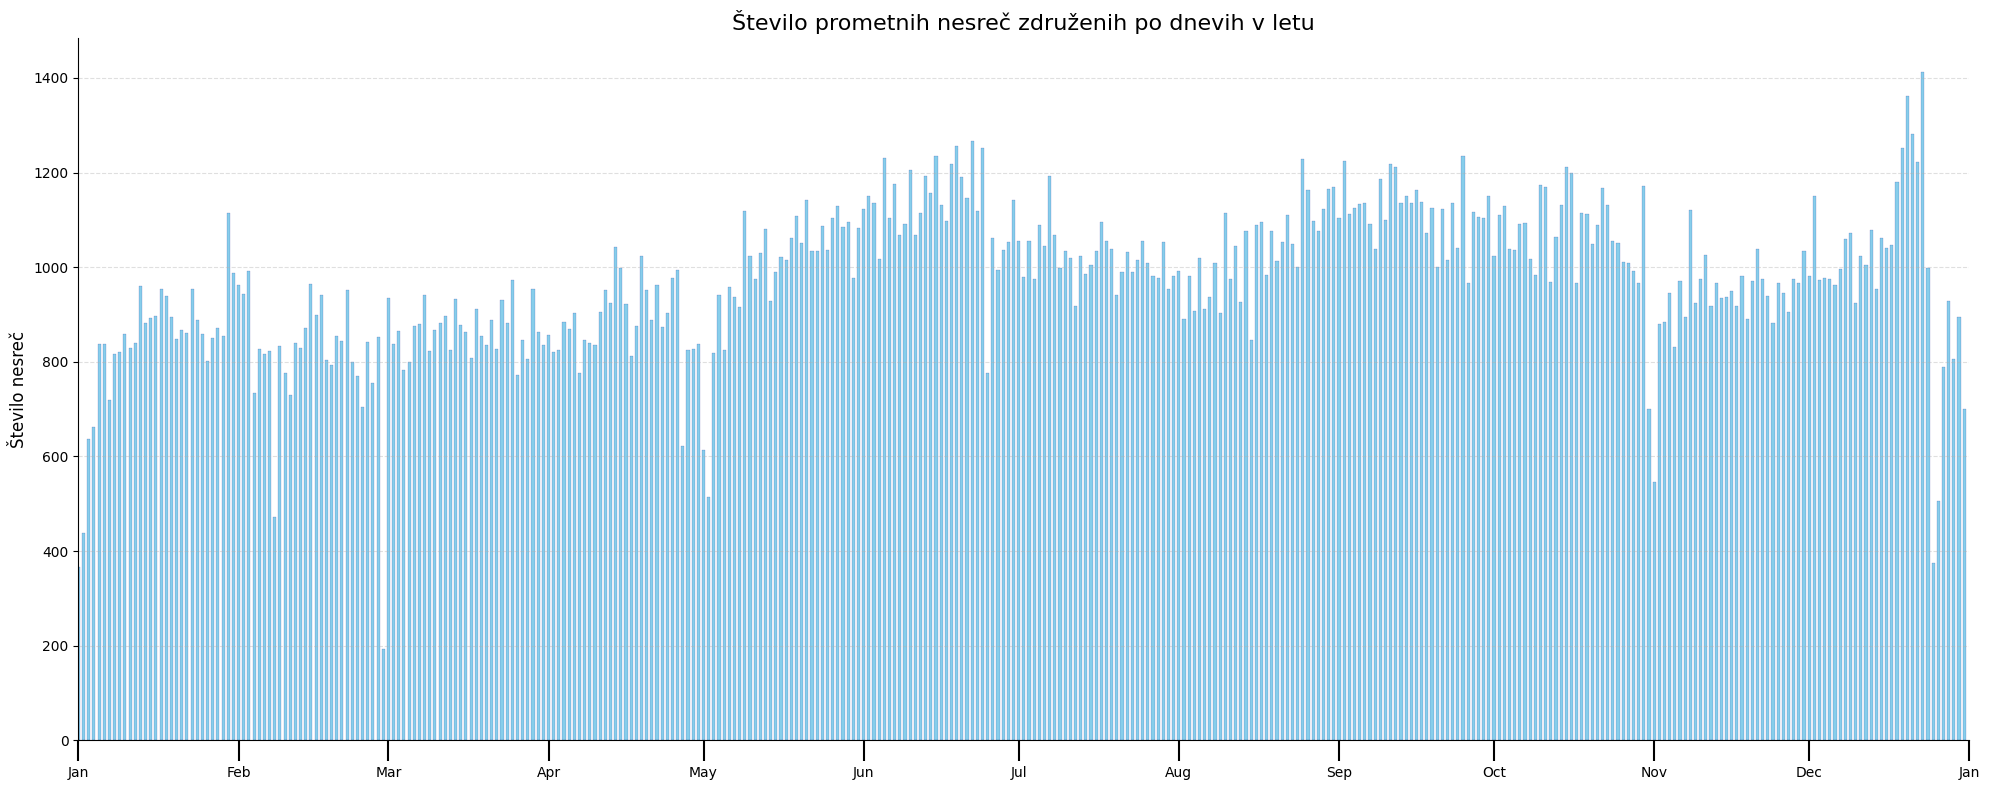

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

master_df = pd.read_csv("merged_clean.csv")

master_df['DatumPN'] = pd.to_datetime(master_df['DatumPN'], dayfirst=True)
daily_counts = master_df.groupby([
    master_df['DatumPN'].dt.month, 
    master_df['DatumPN'].dt.day
]).size()

#Use 2024 to draw x axis ticks since it was a leap year
plot_dates = [pd.Timestamp(year=2024, month=m, day=d) for m, d in daily_counts.index]
counts = daily_counts.values

plt.figure(figsize=(20, 8))

plt.bar(plot_dates, counts, width=0.6, color='skyblue', edgecolor='navy', linewidth=0.1) 

ax = plt.gca()
ax.set_xlim(pd.Timestamp('2024-01-01'), pd.Timestamp('2025-01-01'))

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

ax.tick_params(axis='x', which='major', length=15, width=1.5, direction='out', color='black')

plt.title('Število prometnih nesreč združenih po dnevih v letu', fontsize=16)
plt.ylabel('Število nesreč', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.4)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()



Iz grafa lahko razberemo nekaj zanimivih datumov, kjer so nesreče manj verjetne. Večinoma se dnevi z manj nesrečami ujemajo z dela prostimi dnevi, kot so praznik dela, dan državnosti in božičem. Okoli božiča je še posebej izrazit "naval" pred praznikom in majhna verjetnost po prazniku, ki narašča vse do novega leta, kjer se ponovno zmanjša. Vidimo lahko tudi, da sta v povprečju najnevarnejši obdobji pred božičem in meseci v začetku poletja

Še ena posebnost, ki jo velja omeniti je 29. februar, ki se zaradi prestopnega leta v podatkih pojavi štirikrat manj kot ostali, vendar to še ne pomeni, da je ta dan bolj "varen".

### 2. Katere ure in dnevi v tednu so najnevarnejši?
Tukaj podobno. Iz datumov posamezno izluščimo datume in ure, ter jih združimo. Združene pojavitve preštejemo, da dobimo količino.

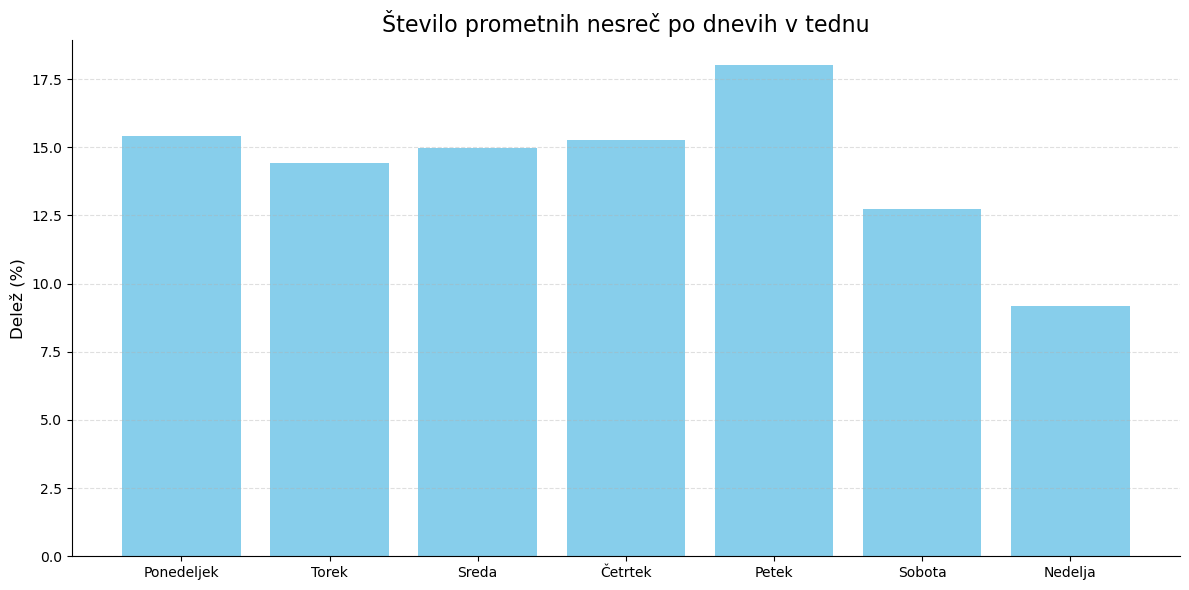

In [29]:
# Reset master_df to its original state (we are changing it in each exercise, so it makes sense to create a clean one)
master_df = pd.read_csv("merged_clean.csv")


master_df['DatumPN'] = pd.to_datetime(master_df['DatumPN'], dayfirst=True)

weekday_counts = master_df.groupby(master_df['DatumPN'].dt.dayofweek).size()

weekday_ratio = weekday_counts / weekday_counts.sum() * 100

days = ['Ponedeljek', 'Torek', 'Sreda', 'Četrtek', 'Petek', 'Sobota', 'Nedelja']

plt.figure(figsize=(12, 6))

plt.bar(days, weekday_ratio, width=0.8, color='skyblue', edgecolor='none')

ax = plt.gca()

plt.title('Število prometnih nesreč po dnevih v tednu', fontsize=16)
plt.ylabel('Delež (%)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.4)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


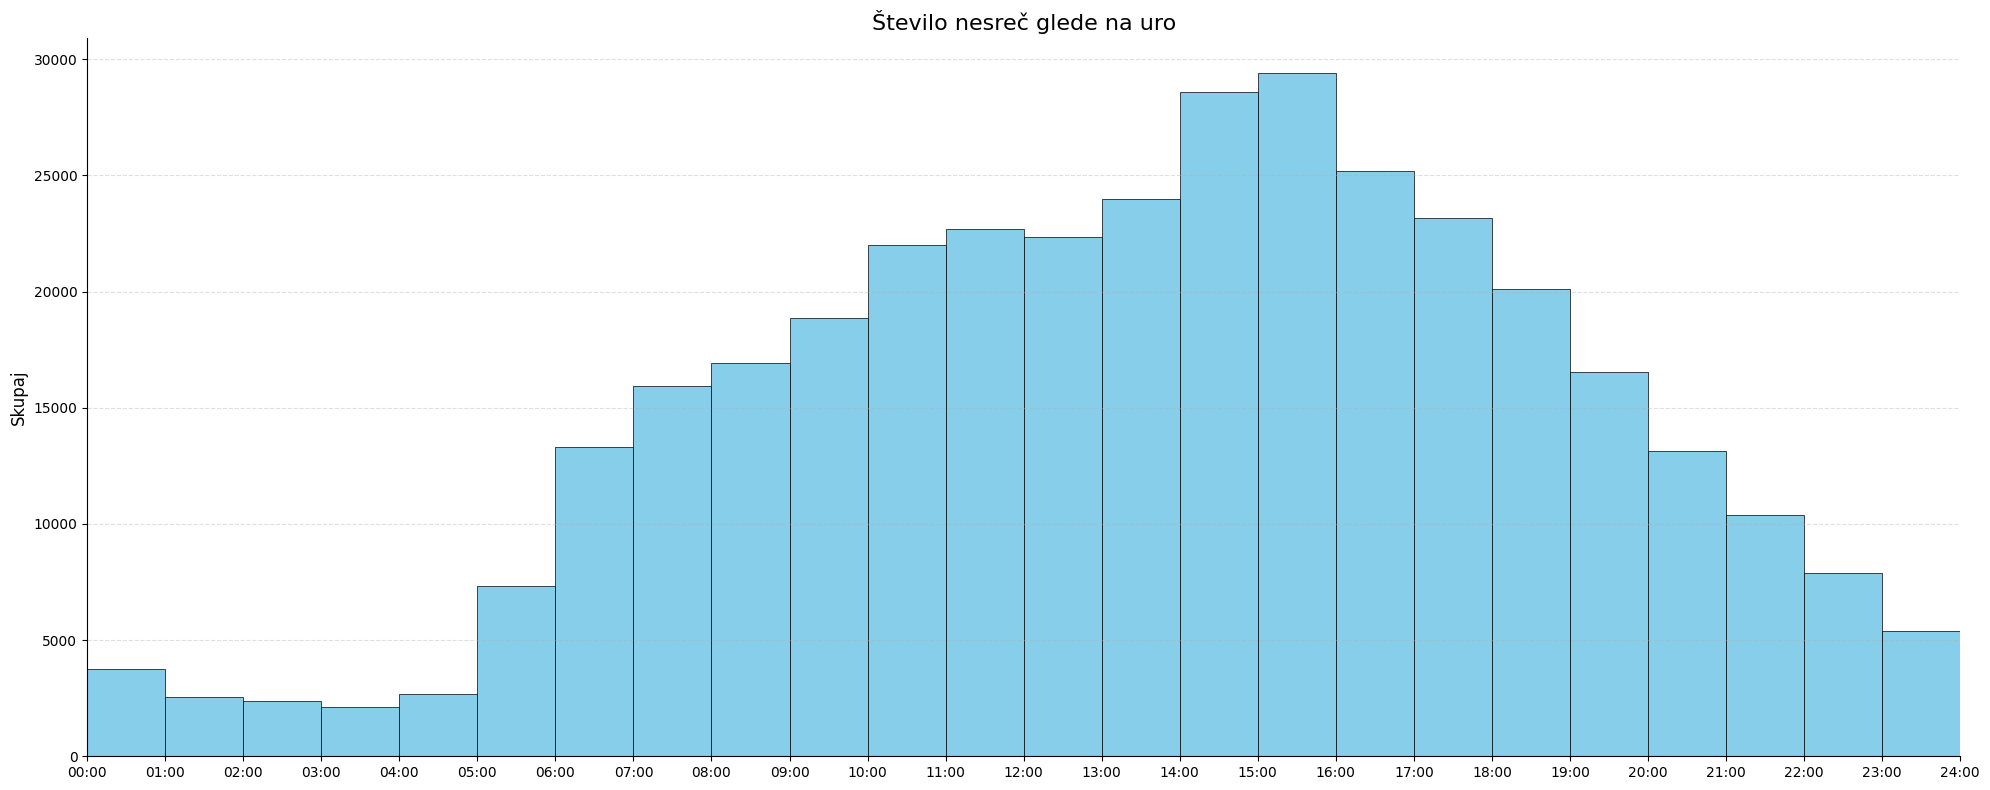

In [13]:
master_df = pd.read_csv("merged_clean.csv") 

master_df['hour'] = master_df['UraPN'].astype(str).str.extract(r'(\d+)').astype(float).fillna(0).astype(int)
master_df['hour'] = master_df['hour'].clip(0, 23)

hourly_counts = master_df.groupby('hour').size().reindex(range(24), fill_value=0)

plt.figure(figsize=(20, 8))

plt.bar(hourly_counts.index, hourly_counts.values, width=1.0, color='skyblue', edgecolor='black', linewidth=0.5, align='edge')

ax = plt.gca()
ax.set_xticks(range(0, 25))
ax.set_xticklabels([f"{h:02d}:00" for h in range(25)])
ax.set_xlim(0, 24)

plt.title('Število nesreč glede na uro', fontsize=16)
plt.ylabel('Skupaj', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.4)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

Tudi pri teh dveh primerih so podatki povsem pričakovani

### 3. V kakšnem vremenu so verjetne "hude" nesreče?

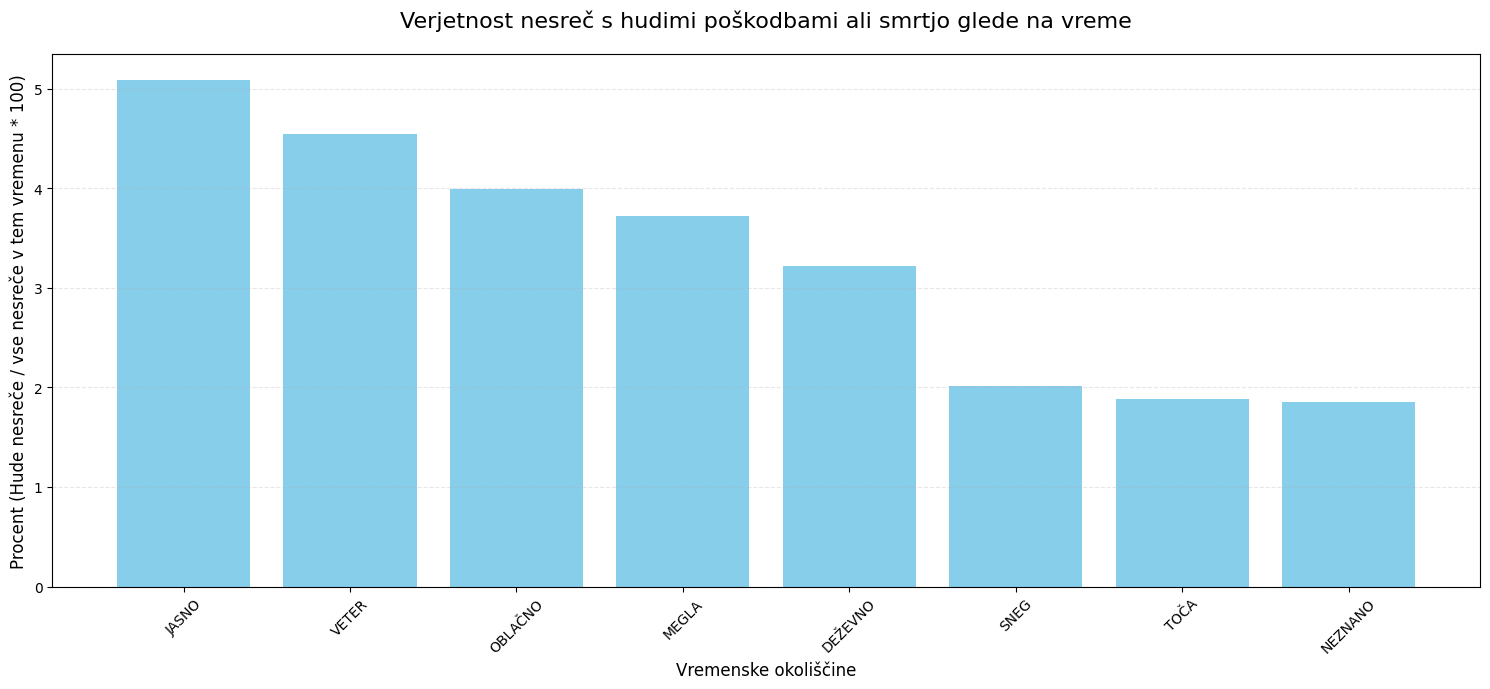

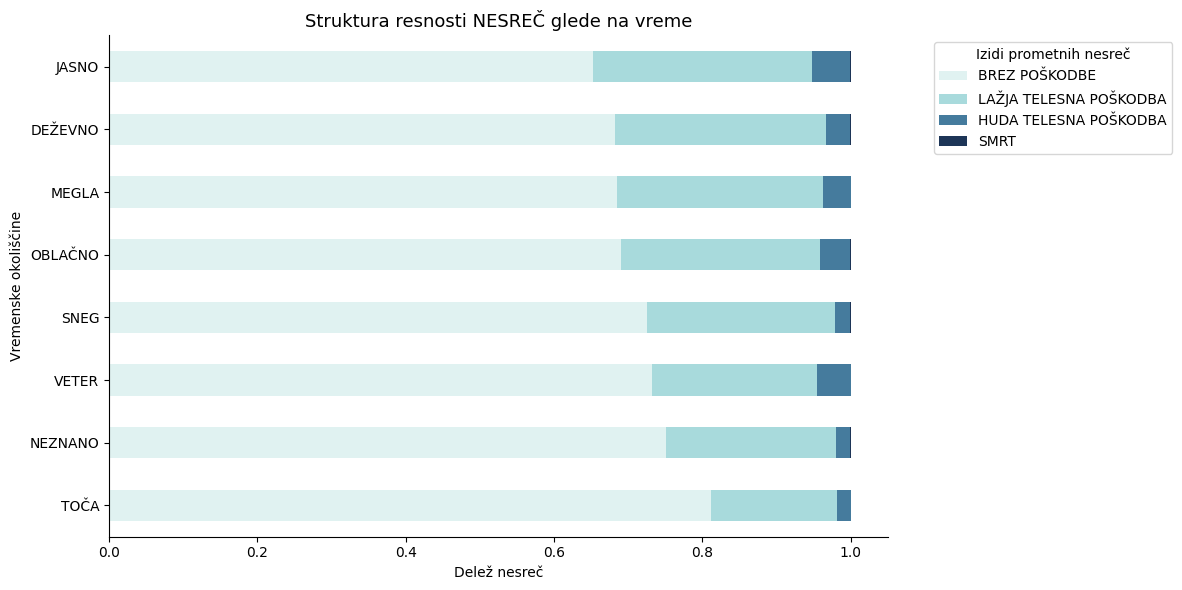

In [17]:
master_df = pd.read_csv("merged_clean.csv") 

hujse_kategorije = ['S SMRTNIM IZIDOM', 'HUDA TELESNA POŠKODBA'] 

total_per_weather = master_df.groupby('VremenskeOkoliscine')['ID'].nunique()

heavy_accidents_df = master_df[master_df['PoskodbaUdelezenca'].isin(hujse_kategorije)]
heavy_per_weather = heavy_accidents_df.groupby('VremenskeOkoliscine')['ID'].nunique()

normalized_ratios = ((heavy_per_weather / total_per_weather) * 100).fillna(0).sort_values(ascending=False)

plt.figure(figsize=(15, 7))
bars = plt.bar(normalized_ratios.index, normalized_ratios.values, color='skyblue')

plt.title('Verjetnost nesreč s hudimi poškodbami ali smrtjo glede na vreme', fontsize=16, pad=20)
plt.ylabel('Procent (Hude nesreče / vse nesreče v tem vremenu * 100)', fontsize=12)
plt.xlabel('Vremenske okoliščine', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()




kategorije_resnosti = {'BREZ POŠKODBE': 0,'Z MATERIALNO ŠKODO': 1,'LAŽJA TELESNA POŠKODBA': 2,'HUDA TELESNA POŠKODBA': 3,
                       'S SMRTNIM IZIDOM': 4}

master_df['Resnost_Rank'] = master_df['PoskodbaUdelezenca'].map(kategorije_resnosti)

df_nesrece = master_df.sort_values(['ID', 'Resnost_Rank'], ascending=[True, False]).drop_duplicates('ID')

summary = df_nesrece.groupby(['VremenskeOkoliscine', 'PoskodbaUdelezenca']).size().unstack().fillna(0)

vrstni_red_izidov = ['BREZ POŠKODBE', 'LAŽJA TELESNA POŠKODBA', 'HUDA TELESNA POŠKODBA', 'SMRT']
obstojeci_stolpci = [c for c in vrstni_red_izidov if c in summary.columns]
summary = summary[obstojeci_stolpci]

summary_pct = summary.div(summary.sum(axis=1), axis=0)

if 'HUDA TELESNA POŠKODBA' in summary_pct.columns:
    col_sort = 'BREZ POŠKODBE'
    summary_pct = summary_pct.sort_values(by=col_sort, ascending=False)

my_colors = ['#E0F2F1', '#A8DADC', '#457B9D', '#1D3557']
ax = summary_pct.plot(kind='barh', stacked=True, figsize=(12, 6), color=my_colors[:len(summary_pct.columns)])

plt.title('Struktura resnosti NESREČ glede na vreme', fontsize=13)
plt.xlabel('Delež nesreč')
plt.ylabel('Vremenske okoliščine')
plt.legend(title='Izidi prometnih nesreč', bbox_to_anchor=(1.05, 1), loc='upper left')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

Pri analizi smo želeli ugotoviti korelacijo med hujšimi prometnimi nesrečami (tistimi s smrtnim izidom ali hudo telesno poškodbo) in vremenskimi okoliščinami. Ker se velika večina vseh nesreč zgodi ob idealnih pogojih, smo podatke normalizirali. Verjetnost smo izračunali kot razmerje - **hude nesreče v nekem vremenu / vse nesreče v nekem vremenu**.

Rezultati so nekoliko presenetljivi, saj se izkaže, da je verjetnost za najhujše posledice največja prav ob jasnem vremenu, kjer je verjetnost za nastanek približno 5%. Takoj na drugem mestu je nepričakovano vetrovno vreme kar morda kaže na šum v podatkih. Veter je sekundarna vremenska okoliščina, ki se lahko pojavi tako pri jasnem kot slabem vremenu, zato je težko oceniti ali je veter dejansko pripomoral k nastanku nesreče. Razmere, ki jih intuitivno smatramo za nevarnejše (dež, sneg, toča), na spodnjem delu lestvice. Sklepamo lahko, da so vozniki v zahtevnejših razmerah, kot sta sneg ali dež, precej bolj previdni in počasnejši, kar zmanjšuje silovitost trčenj, čeprav je število manjših nesreč (npr. zdrsov) v takem vremenu lahko večje.


### 3. Letni trend vožnje pod vplivom alkohola med mladimi vozniki.

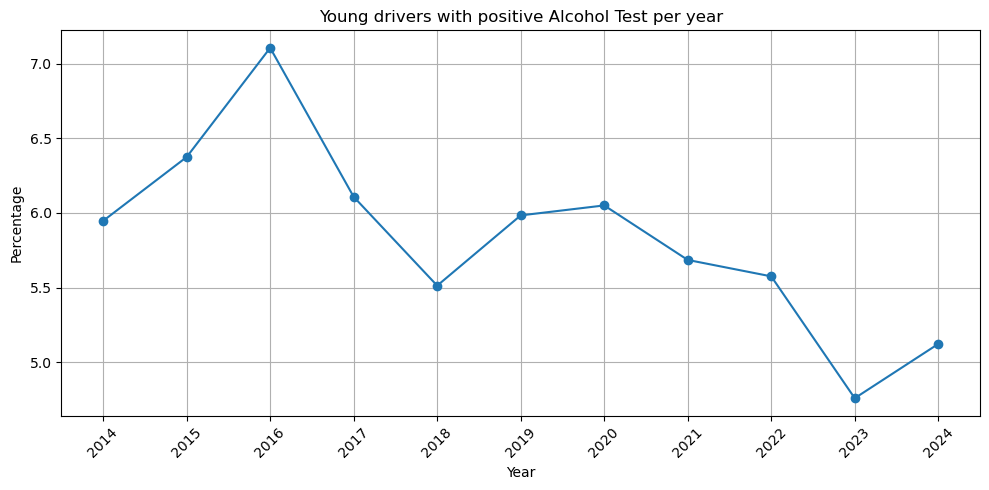

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

master_df = pd.read_csv("merged_clean.csv")
master_df['Starost'] = master_df['Starost'].replace(" ", None)
master_df['Starost'] = pd.to_numeric(master_df['Starost'], errors='coerce')
master_df['VrednostAlkotesta'] = pd.to_numeric(master_df['VrednostAlkotesta'], errors='coerce')
master_df['DatumPN'] = pd.to_datetime(master_df['DatumPN'], dayfirst=True)

young_drivers_alcohol = master_df[(master_df['Starost'] > 12) & (master_df['Starost'] < 30) & (master_df['VrednostAlkotesta'] > 0)]
young_drivers_all = master_df[(master_df['Starost'] > 12) & (master_df['Starost'] < 30)]

alcohol_yearly = young_drivers_alcohol.groupby(young_drivers_alcohol['DatumPN'].dt.year).size()
all_yearly = young_drivers_all.groupby(young_drivers_all['DatumPN'].dt.year).size()

ratio = (alcohol_yearly / all_yearly) * 100

plt.figure(figsize=(10, 5))
plt.plot(ratio.index, ratio.values, marker="o")
plt.title('Young drivers with positive Alcohol Test per year')
plt.xlabel('Year')
plt.ylabel('Percentage')
plt.xticks(ratio.index, rotation= 45)
plt.grid(True)
plt.tight_layout()
plt.show()

Če upoštevamo, da je bilo leto 2020 odstopajoče zaradi COVID-19, lahko rečemo, da med mladimi vozniki vožnja pod vplivom alkohola upada, pri čemer so prisotna le manjša odstopanja.

### 4. Odločitveno drevo za napoved izida nesreče glede na nekaj atributov

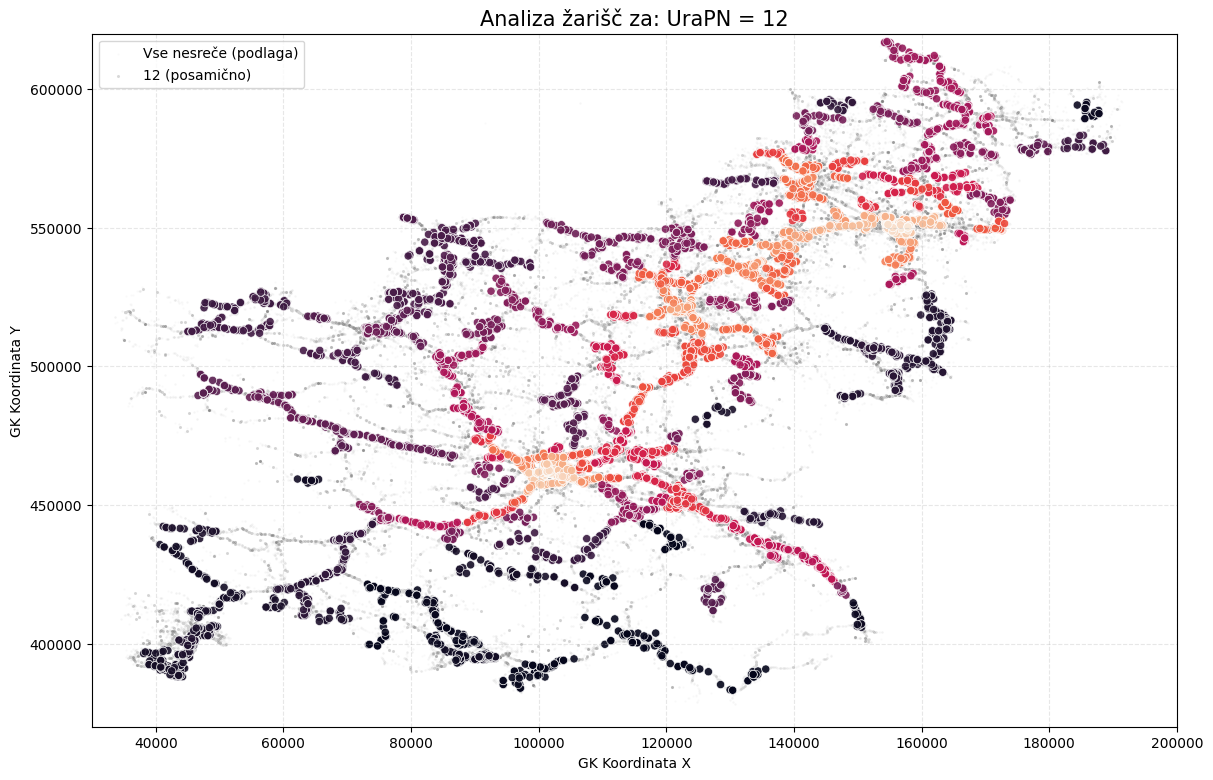

In [77]:
import hdbscan
import seaborn as sns
import matplotlib.pyplot as plt

# --- NASTAVITVE ZA SPREMINJANJE ---
# Tukaj določiš, kateri atribut in katero vrednost želiš analizirati
target_attribute = 'UraPN'     # npr. 'Starost', 'VrednostAlkotesta', 'Spol', 'VzrokNesrece'
#target_value = 12 # npr. vrednost, ki jo iščeš v tem stolpcu
# Za starost lahko uporabiš npr: master_df_clean[master_df_clean['Starost'] < 25]

# 1. FILTRIRANJE PODATKOV glede na tvoj "Target"
# Izberemo samo tiste nesreče, ki ustrezajo tvojemu pogoju
df_target = master_df_clean[(master_df_clean['UraPN'] > 0 ) & (master_df_clean['UraPN'] < 6)].copy()
#df_target = master_df_clean[master_df_clean[target_attribute] == target_value].copy()

# 2. GRUČENJE (HDBSCAN) na filtriranih podatkih
# Opomba: Če je vzorec majhen, zmanjšaj min_cluster_size (npr. na 10 ali 15)
clusterer = hdbscan.HDBSCAN(min_cluster_size=15, min_samples=5)
df_target['Cluster'] = clusterer.fit_predict(df_target[['GeoKoordinataX', 'GeoKoordinataY']])

# 3. VIZUALIZACIJA
plt.figure(figsize=(14, 9))

# Podlaga: Vse nesreče v sivi, da vidimo obris Slovenije
plt.scatter(master_df_clean['GeoKoordinataX'], master_df_clean['GeoKoordinataY'], 
            color='lightgray', s=1, alpha=0.05, label='Vse nesreče (podlaga)')

# Izris filtriranih gruč
# Šum (posamični primeri tvojega targeta)
sns.scatterplot(data=df_target[df_target.Cluster == -1], 
                x='GeoKoordinataX', y='GeoKoordinataY', 
                color='gray', s=5, alpha=0.3, label=f'{target_value} (posamično)')

# Vroče točke tvojega targeta
sns.scatterplot(data=df_target[df_target.Cluster != -1], 
                x='GeoKoordinataX', y='GeoKoordinataY', 
                hue='Cluster', palette='rocket', s=35, alpha=0.9, legend=False)

plt.xlim(30000, 200000)
plt.ylim(370000, 620000)

plt.title(f'Analiza žarišč za: {target_attribute} = {target_value}', fontsize=15)
plt.xlabel('GK Koordinata X')
plt.ylabel('GK Koordinata Y')
plt.grid(True, linestyle='--', alpha=0.3)

plt.show()



In [69]:
with pd.option_context('display.max_rows', None):
    print(master_df["TipNesrece"].value_counts(dropna=False))

TipNesrece
BOČNO TRČENJE                           72244
TRČENJE V STOJEČE / PARKIRANO VOZILO    55024
NALETNO TRČENJE                         53645
OPLAŽENJE                               51845
ČELNO TRČENJE                           33517
OSTALO                                  30065
TRČENJE V OBJEKT                        29706
PREVRNITEV VOZILA                       15538
POVOŽENJE PEŠCA                         10519
POVOŽENJE ŽIVALI                         3645
TRČENJE V KOLESARJA                       873
Name: count, dtype: int64


In [60]:
master_df.columns


Index(['Unnamed: 0', 'ZaporednaStevilkaPN', 'KlasifikacijaNesrece',
       'UpravnaEnotaStoritve', 'DatumPN', 'UraPN', 'VNaselju', 'Lokacija',
       'VrstaCesteNaselja', 'SifraCesteNaselja', 'TekstCesteNaselja',
       'SifraOdsekaUlice', 'TekstOdsekaUlice', 'StacionazaDogodka',
       'OpisKraja', 'VzrokNesrece', 'TipNesrece', 'VremenskeOkoliscine',
       'StanjePrometa', 'StanjeVozisca', 'VrstaVozisca', 'GeoKoordinataX',
       'GeoKoordinataY', 'ZaporednaStevilkaOsebeVPN', 'Povzrocitelj',
       'Starost', 'Spol', 'UEStalnegaPrebivalisca', 'Drzavljanstvo',
       'PoskodbaUdelezenca', 'VrstaUdelezenca', 'UporabaVarnostnegaPasu',
       'VozniskiStazVLetih', 'VozniskiStazVMesecih', 'VrednostAlkotesta', 'ID',
       'Target', 'Cluster'],
      dtype='object')